## Device


In [1]:
shared_folder_Path = "/media/marina/01DB47DC6EBB7DC0/ThreeD/shared"[:-6]
path = '/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo/'
path_model= '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/2_stacked/'
import sys,os, glob, torch
import pickle
sys.path.insert(1,shared_folder_Path)
try:
    os.mkdir('')
except:
    pass

paths_train = glob.glob(path + "/train/*")
paths_test  = glob.glob(path + "/test/*")
paths_test_low = [p for p in paths_test if ('motion_5' in p)]
paths_test_mid = [p for p in paths_test if ('motion_15' in p)]
paths_test_hgh = [p for p in paths_test if ('motion_25' in p)]
len(paths_train), len(paths_test_low), len(paths_test_hgh),len(paths_test)

(3, 400, 400, 1200)

## Import

In [2]:
%load_ext autoreload
%autoreload 2

from torcheval.metrics import PeakSignalNoiseRatio
import torch
from torch.optim import lr_scheduler
from torch.autograd import Variable
import numpy as np
import random
from tqdm import tqdm
import nibabel as nib
from shared.plot import plot_2_Imgs, plot_3_Imgs, plot_4_Imgs, plot_Img
from torch.utils.data import Dataset, DataLoader
from shared.ssim import SSIM
ssim_calc = SSIM()
from torchvision import transforms
import torch.nn.functional as F
from scipy import ndimage
sys.path.append('src/')


def get_n_params( model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn

    return pp


# Deterministic for spectral norm
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
def init_seeds(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(0)
    # no change in alg
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
init_seeds(42)

## Data

In [3]:
import torch
from torch.fft import fftn, fftshift, ifftn, ifftshift
import torchvision
import torch.nn.functional as F

vflip = lambda a: torchvision.transforms.functional.vflip(a)
hflip = lambda a: torchvision.transforms.functional.hflip(a)


def pad(arr,pad_to):

    arr = F.pad( arr, ((pad_to-arr.shape[1])//2, (pad_to-arr.shape[1])//2,
                       (pad_to-arr.shape[0])//2, (pad_to-arr.shape[0])//2), mode='constant', value=0)

    return arr


def real_2_complex_shape(arr):
    if(len(arr.shape)==4 and arr.shape[1]==2):
        k_out2 = arr[:,0:1,:,:] + 1j* arr[:,1:2,:,:]
    if(len(arr.shape)==3 and arr.shape[0]==2):
        k_out2 = arr[0:1,:,:] + 1j* arr[1:2,:,:]

    return k_out2

def print_mini_maxi(arr):
    print(arr.min(), arr.max())
    
def FFT(x):
    return fftshift(fftn(ifftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def IFFT(x):
    return ifftshift(ifftn(fftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def norm_0_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))
    return arr
def norm_1_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))*2-1
    return arr


def normImg(x: torch.Tensor):

    # group norm
    c, h, w = x.shape
    x = x.reshape(1, c // 1 * h * w)
  
    mean = x.mean(dim=2).view(1, 1, 1)
    std = x.std(dim=2).view(1, 1, 1)
    x = x.view(c, h, w)
  
  
    return (x - mean) / std, mean, std


def convert_polar_to_cylindrical( magnitude, phase):

    real = magnitude * torch.cos(phase)
    imag = magnitude * torch.sin(phase)
    return real, imag


def convert_cylindrical_to_polar(real,imag):

    mag = (real ** 2 + imag ** 2) ** (0.5)
    phase = torch.atan2(imag, real)
    phase[phase.ne(phase)] = 0.0  # remove NANs if any
    return mag, phase

def normalized_complex_mag(arr):

    mag, phase = convert_cylindrical_to_polar(arr.real,arr.imag)
    normalized_magnitude = (mag - torch.mean(mag)) / (torch.std(mag))
    real,imag = convert_polar_to_cylindrical(normalized_magnitude,phase)
    normed = real+1j*imag 

    return normed


In [4]:
def preprocess(kspace, k_space_artifact,Main_Artifact_path,mask):

    # IFFT
    image_Complex = IFFT(kspace)
    image_artifact_Complex = IFFT(k_space_artifact)
    
    # Img
    image = image_Complex.abs()
    image_artifact = image_artifact_Complex.abs()
    
    # Norm img
    image = norm_0_1(image)
    image_artifact = norm_0_1(image_artifact)
    

    # View
    kspace = torch.view_as_real(kspace)
    kspace = torch.moveaxis(kspace,-1,0)
    k_space_artifact = torch.view_as_real(k_space_artifact)
    k_space_artifact = torch.moveaxis(k_space_artifact,-1,0)
    image_Complex = torch.view_as_real(image_Complex)
    image_Complex = torch.moveaxis(image_Complex,-1,0)
    image_artifact_Complex = torch.view_as_real(image_artifact_Complex)
    image_artifact_Complex = torch.moveaxis(image_artifact_Complex,-1,0)


    return  {"Arr":image[None,...],
             "Arr_Complex":image_Complex,
                "Art":image_artifact[None,...],
             "Art_Complex":image_artifact_Complex,
                "K_Arr":kspace,
                "K_Art":k_space_artifact,
                'path':Main_Artifact_path,
            }

class MRIDataset(Dataset):
    def __init__(self, imgs_paths):
        self.imgs_paths = imgs_paths
    def __len__(self):
        return len(self.imgs_paths)
    def __getitem__(self, index):

        Main_Artifact_path = self.imgs_paths[index]
        kspace,k_space_artifact,mask = torch.load(Main_Artifact_path, weights_only=False)
        return  preprocess(kspace,k_space_artifact,Main_Artifact_path, mask)

3 1200
/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo//test/e14258s3_P76800.7._slice_78_motion_25.pt
BLUR:  tensor([0.2126])


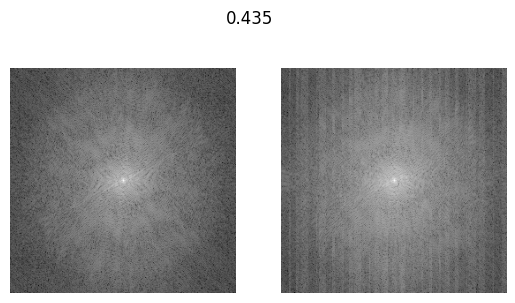

BLUR:  tensor([0.4792])


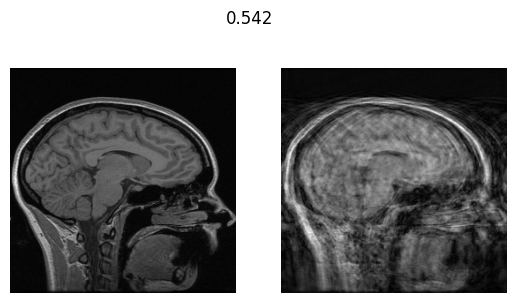

In [5]:
#dataset
dataset_train = MRIDataset(paths_train)
dataset_val = MRIDataset(paths_test)
print(len(dataset_train), len(dataset_val))

#dataloaders
batch_size = 8
dataloaders = dict()
dataloaders['train'] = DataLoader(dataset_train, batch_size=batch_size,
                                   shuffle=True, pin_memory=True)
dataloaders['val'] = DataLoader(dataset_val, batch_size=batch_size,
                                shuffle=False, pin_memory=True)
sample = dataset_val[random.randint(0,len(dataset_val))]

device = 'cuda'    
with torch.no_grad():
    print(sample['path'])
    Arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    
    K_Art = sample['K_Art'].to(device)
    K_Arr = sample['K_Arr'].to(device)
    K_Art = torch.view_as_complex(torch.moveaxis(K_Art,0,-1))
    K_Arr = torch.view_as_complex(torch.moveaxis(K_Arr,0,-1))
    
    plot_2_Imgs(K_Arr.abs().add(1e-9).log(),K_Art.abs().add(1e-9).log())
    plot_2_Imgs(Arr,Art)

## Model

In [6]:
device='cuda'
from networks import *
netG_A = define_G(input_nc=1,output_nc=1,ngf=64,netG='unet_256')
netG_A = torch.load("/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/0_cycleGan/29_netG_A_model.pt",'cuda',weights_only=False)
netG_B = define_G(input_nc=1,output_nc=1,ngf=64,netG='unet_256')
#netG_B = torch.load("/kaggle/input/cyclegan-48/48_netG_B_model.pt",weights_only=False)
netG_A = netG_A.to(device=device)
netG_B = netG_B.to(device=device)
print(get_n_params(netG_A))

initialize network with normal
initialize network with normal
54407809


-1034


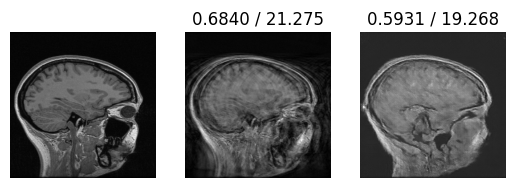

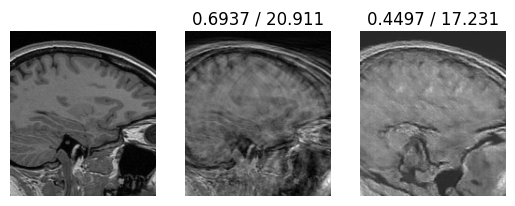

BLUR: 0.406 aes:0.01111


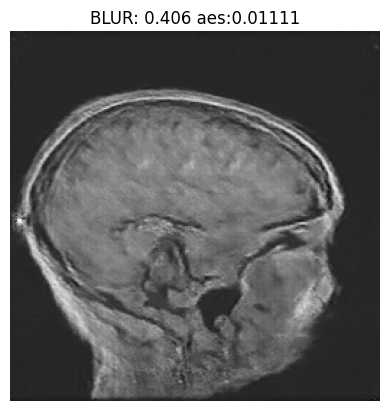

In [7]:
p = -1034#random.randint(0,len(dataset_val))
print(p)
sample= dataset_val[p]

with torch.no_grad():
    real_A = sample['Art'][None].to(device)
    real_B = sample['Arr'][None].to(device)
    fake_B = netG_A(real_A)
    rec_A  = netG_B(fake_B)
    fake_A = netG_B(real_B)
    rec_B = netG_A(fake_A)
  
    #plot_Img(real_A)
    #plot_Img(fake_B)
    #plot_Img(real_A[:,:,50:-50,50:-50])
    
    torch.save(fake_B,'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Cycle_' + str(p) +'.pt')
    torch.save(fake_B[:,:,30:-63,30:-70],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/Cycle_sm_' + str(p) +'.pt')

    #plot_Img(fake_B[:,:,50:-50,50:-50])
    plot_3_Imgs(sample['Arr'][0],sample['Art'][0],fake_B[0,0])
    plot_3_Imgs(sample['Arr'][:,30:-50,50:-50],sample['Art'][:,30:-50,50:-50],fake_B[:,:,30:-50,50:-50])
    plot_Img(fake_B[0,0])

In [8]:
netD_A = define_D(netD="basic",input_nc=1,ndf=64)
netD_A = netD_A.to(device=device)
netD_B = define_D(netD="basic",input_nc=1,ndf=64)
netD_B = netD_B.to(device=device)

print(get_n_params(netD_A))
with torch.no_grad():
    out_dis = netD_B(fake_A)
    print(out_dis.shape)

initialize network with normal
initialize network with normal
2761793
torch.Size([1, 1, 30, 30])


## Outer

In [9]:
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)


input_img_3DNuFFT_sub8_run04 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run04.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = torch.view_as_complex(input_img_3DNuFFT_sub8_run04)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = F.pad( input_img_3DNuFFT_sub8_run04, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run04.shape)

input_img_3DNuFFT_sub8_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run00.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run00.shape)
#input_img_3DNuFFT_sub8_run00 = torch.view_as_complex(input_img_3DNuFFT_sub8_run00)
print(input_img_3DNuFFT_sub8_run00.shape)
input_img_3DNuFFT_sub8_run00 = F.pad( input_img_3DNuFFT_sub8_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run00.shape)


input_img_3DNuFFT_sub1_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-00_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = torch.view_as_complex(input_img_3DNuFFT_sub1_run00)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = F.pad( input_img_3DNuFFT_sub1_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run00.shape)

input_img_3DNuFFT_sub1_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = torch.view_as_complex(input_img_3DNuFFT_sub1_run01)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = F.pad( input_img_3DNuFFT_sub1_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run01.shape)


input_img_3DNuFFT_sub2_run02 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = torch.view_as_complex(input_img_3DNuFFT_sub2_run02)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = F.pad( input_img_3DNuFFT_sub2_run02, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub2_run02.shape)


input_img_3DNuFFT_sub2_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-01_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run01 = torch.view_as_complex(input_img_3DNuFFT_sub2_run01)
input_img_3DNuFFT_sub2_run01 = F.pad( input_img_3DNuFFT_sub2_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)

input_img_3DNuFFT_sub2_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-00_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run00 = torch.view_as_complex(input_img_3DNuFFT_sub2_run00)
input_img_3DNuFFT_sub2_run00 = F.pad( input_img_3DNuFFT_sub2_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)

torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])


105
torch.Size([256, 256])
tensor([0.4555], device='cuda:0')
BLUR: 0.455 aes:0.00927


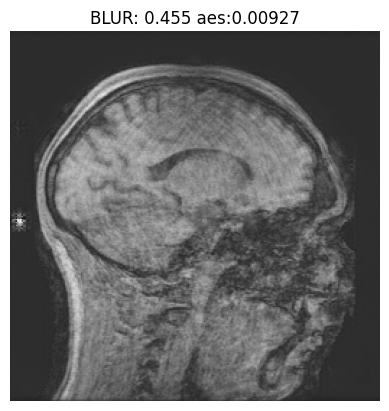

In [12]:
aa = input_img_3DNuFFT_sub2_run02
with torch.no_grad():
    t = 105#t+10
    print(t)

    Art = aa[:,t]
    print(Art.shape)
    Art = torch.tensor(ndimage.rotate(Art, -90))
    Art = abs(Art)[None][None]#.cuda()
    Art = norm_0_1(Art)

    with torch.no_grad():
        
        Real_out = netG_A(Art.cuda()) 
        #torch.save(Real_out[0,0,17:-17,:],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Cycle_REAL.pt')
        print(b(Real_out))
        #plot_2_Imgs(Art,Real_out) 
plot_Img(Real_out)

In [11]:
s

NameError: name 's' is not defined

## Loss & Optimization

In [ ]:
from shared.GradualWarmupSchedulerFile import *
from shared.ssim import SSIM
SSIMcriterion = SSIM().cuda() #mean absolute error
criterionGAN = GANLoss('vanilla').cuda() #mean absolute error

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
learning_rate = 10**-4
optimizer_G = torch.optim.Adam(netG_A.parameters(), lr=learning_rate)
learning_rate = 10**-4
optimizer_D = torch.optim.Adam(netD_A.parameters(), lr=learning_rate)

## Train

In [ ]:
def set_requires_grad( nets, requires_grad=False):
    if not isinstance(nets, list):
        nets = [nets]
    for net in nets:
        if net is not None:
            for param in net.parameters():
                param.requires_grad = requires_grad

criterionIdt = torch.nn.L1Loss()
criterionCycle = torch.nn.L1Loss()

lambda_B = 1; lambda_A = 1; lambda_idt = 1

In [ ]:
num_epochs = 100

for epoch in range(num_epochs):
    ssim_all = 0
    


    pbar_train = tqdm(enumerate(dataloaders['train']), total=len(dataloaders['train']), position=0, leave=True)
    for (i, data) in pbar_train:

        ######################
        # (1) Update G network
        set_requires_grad([netD_A, netD_B], False)  # Ds require no gradients when optimizing Gs
        optimizer_G.zero_grad()
        
        #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # forward
        real_A = Variable(data['Art']).to(device)
        real_B = Variable(data['Arr']).to(device)

        fake_B = netG_A(real_A)  # G_A(A)
        rec_A = netG_B(fake_B)  # G_B(G_A(A))
        fake_A = netG_B(real_B)  # G_B(B)
        rec_B = netG_A(fake_A)  # G_A(G_B(B))


        #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # backward_G
        # G_A should be identity if real_B is fed: ||G_A(B) - B||
        idt_A = netG_A(real_B)
        loss_idt_A = criterionIdt(idt_A, real_B) 
        # G_B should be identity if real_A is fed: ||G_B(A) - A||
        idt_B = netG_B(real_A)
        loss_idt_B = criterionIdt(idt_B, real_A)

        loss_G_A = criterionGAN(netD_A(fake_B), True)
        # GAN loss D_B(G_B(B))
        loss_G_B = criterionGAN(netD_B(fake_A), True)
        # Forward cycle loss || G_B(G_A(A)) - A||
        loss_cycle_A = criterionCycle(rec_A, real_A) * lambda_A
        # Backward cycle loss || G_A(G_B(B)) - B||
        loss_cycle_B = criterionCycle(rec_B, real_B) * lambda_B

        loss_G = loss_G_A + loss_G_B + loss_cycle_A + loss_cycle_B + loss_idt_A + loss_idt_B 

        (loss_G).backward()
        optimizer_G.step()




        #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        set_requires_grad([netD_A, netD_B], True)
        optimizer_D.zero_grad()
        
        #backward_D_A: (self.netD_A, self.real_B, fake_B)
        # Real
        pred_real = netD_A(real_B)
        loss_D_real = criterionGAN(pred_real, True)
        # Fake
        pred_fake = netD_A(fake_B.detach())
        loss_D_fake = criterionGAN(pred_fake, False)
        # Combined loss and calculate gradients
        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()


        #backward_D_A: (self.netD_B, self.real_A, fake_A)
        # Real
        pred_real = netD_B(real_A)
        loss_D_real = criterionGAN(pred_real, True)
        # Fake
        pred_fake = netD_B(fake_A.detach())
        loss_D_fake = criterionGAN(pred_fake, False)
        # Combined loss and calculate gradients
        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()


        optimizer_D.step()



        ssim_all += float(SSIMcriterion(fake_B, real_B).cpu().detach())

        if(i%10==0):
            if((i==0) and (epoch==0)):
                file1 = open(path_model + "log.txt", "w")
            else:
                file1 = open(path_model + "log.txt", "a")
            file1.write("Epoch: " + str(epoch)+ "  , step: " + str(i) + "  , SSIM: " + str(float(ssim_all/(i+1)))+"\n")
            file1.close()


    print("Train SSIM: " ,ssim_all/len(pbar_train))
    file1 = open(path_model + "log.txt", "a")
    file1.write("Epoch: " + str(epoch)+ "  , Train: " + "  , SSIM: " + str(float(ssim_all/len(pbar_train))) + "\n")
    file1.close()


    torch.save(netG_A, path_model+"/"+str(epoch)+"_netG_A_model.pt")
    torch.save(netG_B, path_model+"/"+str(epoch)+"_netG_B_model.pt")
    torch.save(netD_A, path_model+"/"+str(epoch)+"_netD_A_model.pt")
    torch.save(netD_B, path_model+"/"+str(epoch)+"_netD_B_model.pt")


    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    with torch.no_grad():
      ssim_all = 0
      pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
      for (i, datatest) in pbar_test:

            real_A = Variable(datatest['Art']).to(device)
            Arr = Variable(datatest['Arr'].to(device))

            fake_B = netG_A(real_A)  # G_A(A)
            ssim_all +=  float(SSIMcriterion(fake_B, Arr).cpu().detach())


      print("Test SSIM: " ,ssim_all/len(pbar_test))

      file1 = open(path_model + "log.txt", "a")
      file1.write("Epoch: " + str(epoch)+ "  , Test: " + "  , SSIM: " + str(float(ssim_all/len(pbar_test))) + "\n")
      file1.close()

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
from shared.mutualInfo import mutual_information
import time

In [ ]:
with torch.no_grad():
  ssim_all = [] ; psnr_bef=[] ; ssim_all_bef = []
  psnr=[] ; BLUR = [] ; BLUR_BEF = []
  MI = [] ; MI_BEF = []   
  times = []
  pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
  for (i, datatest) in pbar_test:

        path_ = (datatest['path'])[0]
        Arr = Variable(datatest['Arr']).to(device)
        Art = Variable(datatest['Art']).to(device)
            
        a = time.time()
        outputs_test = netG_A(Art)  # G_A(A)
        times.append(time.time()-a)
        
        ssim_all .append(  float(SSIM_criterion(outputs_test, Arr).cpu().detach()))
        ssim_all_bef .append( float(SSIM_criterion(Art, Arr).cpu().detach()))

        metric = PeakSignalNoiseRatio()
        metric.update(outputs_test, Arr)
        paft = float(metric.compute())
        psnr.append( paft)

        metric = PeakSignalNoiseRatio()
        metric.update(Art, Arr)
        pbef = float(metric.compute())
        psnr_bef.append( pbef)

        BLUR .append( torch.sum(b(outputs_test)).cpu().detach())
        BLUR_BEF  .append( torch.sum(b(Art)).cpu().detach())


        MI .append( mutual_information(Arr,outputs_test))
        MI_BEF .append( mutual_information(Arr,Art))


        # save
        if(i==0):do='w'
        else: do = 'a'
        p = '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/0_cycleGan/data/'
        with open(p+ 'ssim_all.txt', do) as f:
            f.write( str(float(SSIM_criterion(outputs_test, Arr).cpu().detach())) + "\n" )
        with open(p+ 'ssim_all_bef.txt', do) as f:
            f.write( str(float(SSIM_criterion(Art, Arr).cpu().detach())) + "\n" )

        with open(p+ 'psnr_all.txt', do) as f:
            f.write( str(paft) + "\n" )
        with open(p+ 'psnr_all_bef.txt', do) as f:
            f.write( str(pbef) + "\n" )

        with open(p+ 'blur_all.txt', do) as f:
            f.write( str(float(torch.sum(b(outputs_test)).cpu().detach()))  + "\n" )
        with open(p+ 'blur_all_bef.txt', do) as f:
            f.write( str(float(torch.sum(b(Art)).cpu().detach())) + "\n" )
        
        with open(p+ 'MI_all.txt', do) as f:
            f.write( str(float(mutual_information(Arr,outputs_test)))  + "\n" )
        with open(p+ 'MI_all_bef.txt', do) as f:
            f.write( str(float(mutual_information(Arr,Art))) + "\n" )
                                                                              
        with open(p+ 'path.txt', do) as f:
            f.write( path_ + "\n" )

100%|██████████| 150/150 [01:52<00:00,  1.34it/s]


In [ ]:
print("ssim aft std :",np.std(ssim_all), "ssim mean :",np.mean(ssim_all))
print("ssim bef std :",np.std(ssim_all_bef), "ssim mean :",np.mean(ssim_all_bef) ,"\n")

print("psnr aft std :",np.std(psnr), "psnr mean :",np.mean(psnr))
print("psnr bef std :",np.std(psnr_bef), "psnr mean :",np.mean(psnr_bef),"\n")

print("Blur aft std :",np.std(BLUR), "Blur mean :",np.mean(BLUR))
print("Blur bef std :",np.std(BLUR_BEF), "Blur mean :",np.mean(BLUR_BEF),"\n")

print("MI aft std :",np.std(MI), "MI mean :",np.mean(MI))
print("MI bef std :",np.std(MI_BEF), "MI mean :",np.mean(MI_BEF),"\n")

print("time std :",np.std(times), "MI mean :",np.mean(times),"\n")

ssim aft std : 0.04717776944839757 ssim mean : 0.5150239425897598
ssim bef std : 0.03438828903781505 ssim mean : 0.7658770525455475 

psnr aft std : 0.3547496940190833 psnr mean : 18.738236185709635
psnr bef std : 1.3964477571097527 psnr mean : 23.101152470906577 

Blur aft std : 0.13643177 Blur mean : 3.0828905
Blur bef std : 0.12765406 Blur mean : 3.5927267 

MI aft std : 0.0397484519711584 MI mean : 0.5005426637765237
MI bef std : 0.08344502497792193 MI mean : 0.8953781361322998 

time std : 0.1293937799601986 MI mean : 0.015490686098734538 

